In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# TA-Lib for indicators
import talib

# PyNance and PyFolio will be used later, we just import them now
import talib                      # technical indicators
import pynance as py              # from GitHub version
import quantstats as qs   

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)


Download AAPL data from the Data folder

In [14]:
df = pd.read_csv("../Data/yfinance_data/Data/AAPL.csv", parse_dates=["Date"], index_col="Date")
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


Flatten MultiIndex columns (if needed) and clean

In [15]:
# ============================================
# Clean the columns (handle MultiIndex case)
# ============================================

# If columns are MultiIndex (like: ('Close', 'TSLA')), flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)  # keep only first level: Open, High, etc.

print("Cleaned columns:", df.columns.tolist())

# Ensure index is datetime and sorted
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()


Cleaned columns: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


EDA: price and volume

         count          mean           std           min           25%  \
Close   3774.0  5.384117e+01  5.506404e+01  2.345299e+00  1.505036e+01   
High    3774.0  5.438380e+01  5.562723e+01  2.459265e+00  1.518304e+01   
Low     3774.0  5.324746e+01  5.444013e+01  2.345299e+00  1.490189e+01   
Open    3774.0  5.380163e+01  5.500918e+01  2.380989e+00  1.500758e+01   
Volume  3774.0  2.640640e+08  2.345629e+08  2.404830e+07  9.581845e+07   

                 50%           75%           max  
Close   2.697581e+01  7.466420e+01  1.962566e+02  
High    2.716884e+01  7.525238e+01  1.977525e+02  
Low     2.683684e+01  7.355355e+01  1.951569e+02  
Open    2.701021e+01  7.412793e+01  1.961674e+02  
Volume  1.667348e+08  3.777410e+08  1.880998e+09  


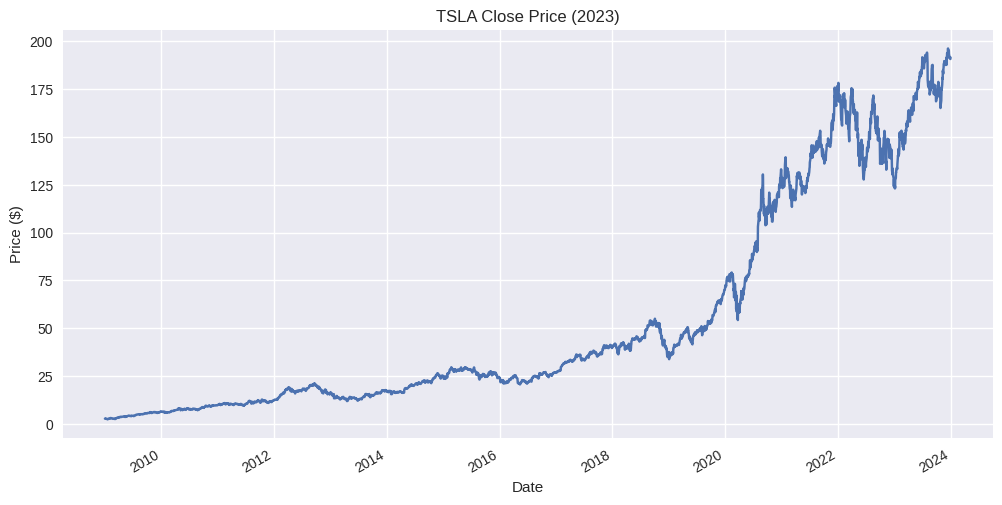

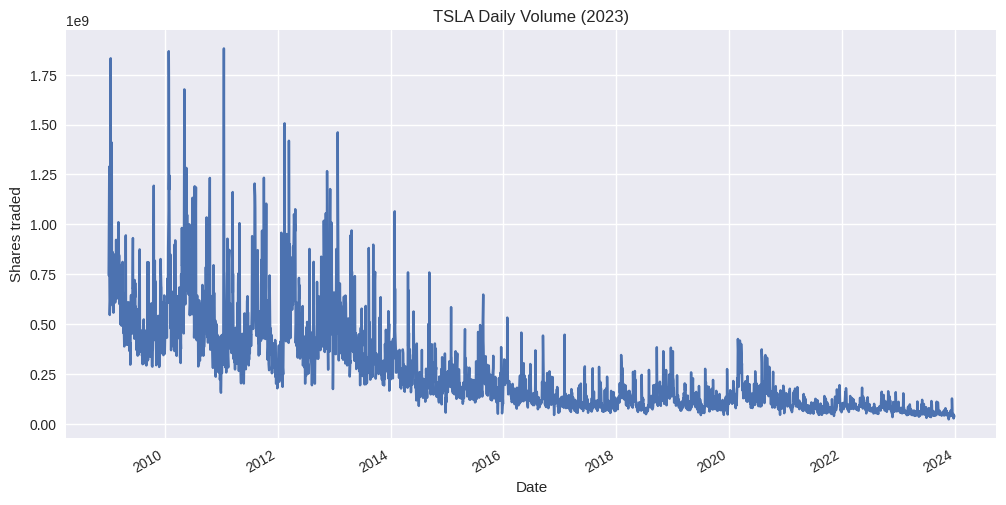

In [16]:
# ============================================
# Quick look at price and volume
# ============================================

print(df.describe().T)

# Close price chart
df["Close"].plot(title="TSLA Close Price (2023)")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="TSLA Daily Volume (2023)")
plt.ylabel("Shares traded")
plt.show()


Add TA-Lib indicators

In [17]:
# ============================================
# Compute technical indicators with TA-Lib
# ============================================

# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,
2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,191.856618,183.572859,191.510231,54.672784,2.633141,3.235256,-0.602115
2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,192.018094,183.858864,191.484867,53.090049,2.304751,3.049155,-0.744404
2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,192.154308,184.149424,191.471353,53.354446,2.029104,2.845145,-0.816041
2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,192.362839,184.479567,191.499696,54.540999,1.823998,2.640915,-0.816918
2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,192.490633,184.814828,191.426275,51.121347,1.559539,2.424640,-0.865101


Plot price + SMA

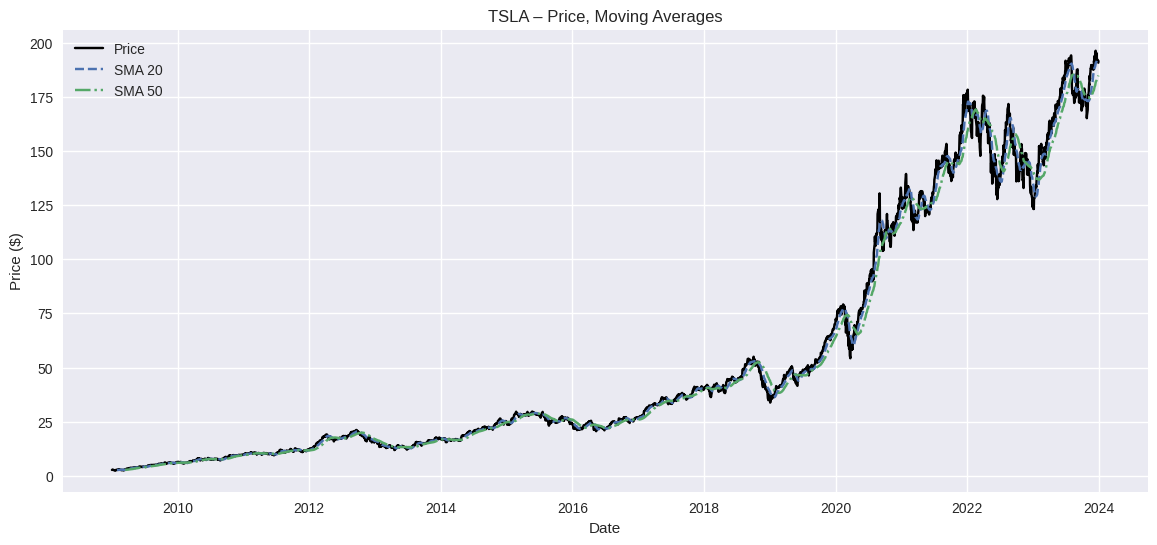

In [18]:
# ============================================
# Price + SMA + Bollinger Bands
# ============================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("TSLA – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


Plot RSI

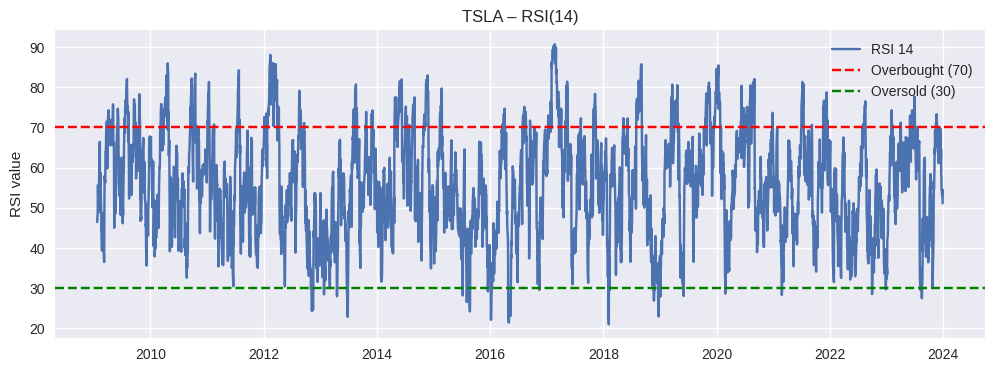

In [19]:
# ============================================
# RSI – Overbought / Oversold
# ============================================

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("TSLA – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


Plot MACD

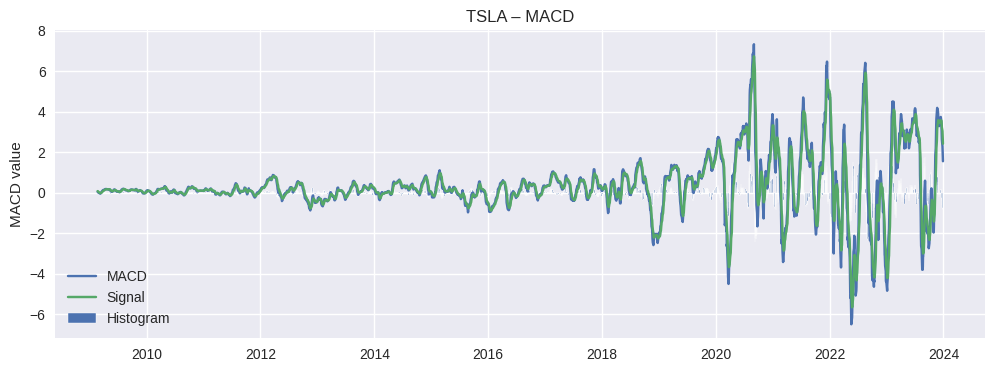

In [20]:
# ============================================
# MACD – Trend & momentum
# ============================================

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("TSLA – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
